# CM3070 Feature Prototype (Kaggle route)
## Deep Learning for Breast Cancer Detection (CBIS-DDSM)

This notebook loads CBIS-DDSM from Kaggle (JPEG images + CSV labels), bypassing TensorFlow Datasets. It implements **Steps 1 to 3** of the Chollet pipeline (framing, data preparation, baseline CNN) plus a short **VGG16 transfer-learning** taste, and evaluates with **AUC-ROC, sensitivity, specificity, and a confusion matrix**.



In [ ]:
# Download the dataset
!pip install -q kaggle
!kaggle datasets download -d awsaf49/cbis-ddsm-breast-cancer-image-dataset
!unzip -q -o cbis-ddsm-breast-cancer-image-dataset.zip -d /content/cbis
print('Done. Top-level contents:')
!ls /content/cbis

Dataset URL: https://www.kaggle.com/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
License(s): CC-BY-SA-3.0
100% 4.95G/4.95G [00:38<00:00, 140MB/s]

Done. Top-level contents:
csv  jpeg


## 1. Inspect the CSV label files

This dataset ships with calc and mass case description CSVs. We inspect them so the label handling is transparent.

In [ ]:
import pandas as pd, glob

csvs = glob.glob('/content/cbis/csv/*.csv')
print('CSV files found:')
for c in csvs:
    print(' ', c)

# Peek at one to see columns
sample = pd.read_csv(csvs[0])
print('\nColumns:', list(sample.columns))
sample.head()

CSV files found:
  /content/cbis/csv/mass_case_description_test_set.csv
  /content/cbis/csv/mass_case_description_train_set.csv
  /content/cbis/csv/meta.csv
  /content/cbis/csv/dicom_info.csv
  /content/cbis/csv/calc_case_description_train_set.csv
  /content/cbis/csv/calc_case_description_test_set.csv

Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']


,patient_id,breast_density,left or right breast,image view,abnormality id,abnormality type,mass shape,mass margins,assessment,pathology,subtlety,image file path,cropped image file path,ROI mask file path
0,P_00016,4,LEFT,CC,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00016_LEFT_CC_1/1.3.6.1.4.1.9590.1...
1,P_00016,4,LEFT,MLO,1,mass,IRREGULAR,SPICULATED,5,MALIGNANT,5,Mass-Test_P_00016_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00016_LEFT_MLO_1/1.3.6.1.4.1.9590....
2,P_00017,2,LEFT,CC,1,mass,ROUND,CIRCUMSCRIBED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_CC/1.3.6.1.4.1.9590.100...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...,Mass-Test_P_00017_LEFT_CC_1/1.3.6.1.4.1.9590.1...
3,P_00017,2,LEFT,MLO,1,mass,ROUND,ILL_DEFINED,4,MALIGNANT,4,Mass-Test_P_00017_LEFT_MLO/1.3.6.1.4.1.9590.10...,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....,Mass-Test_P_00017_LEFT_MLO_1/1.3.6.1.4.1.9590....
4,P_00032,3,RIGHT,CC,1,mass,ROUND,OBSCURED,0,BENIGN,2,Mass-Test_P_00032_RIGHT_CC/1.3.6.1.4.1.9590.10...,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....,Mass-Test_P_00032_RIGHT_CC_1/1.3.6.1.4.1.9590....


In [ ]:
# Look at the directory layout for the images (jpeg folder).
!ls /content/cbis | head
print('---')
!ls /content/cbis/jpeg 2>/dev/null | head || echo 'no jpeg/ folder; checking alternatives'
print('--- dicom_info or meta ---')
!ls /content/cbis/csv

csv
jpeg
---
1.3.6.1.4.1.9590.100.1.2.100018879311824535125115145152454291132
1.3.6.1.4.1.9590.100.1.2.100131208110604806117271735422083351547
1.3.6.1.4.1.9590.100.1.2.100522099512256189513864912954167862869
1.3.6.1.4.1.9590.100.1.2.100522676511025180541602449080267145647
1.3.6.1.4.1.9590.100.1.2.10055294210766234140934516480682841962
1.3.6.1.4.1.9590.100.1.2.100579676611077714807988832023693299884
1.3.6.1.4.1.9590.100.1.2.100631678311747240317898717702514834166
1.3.6.1.4.1.9590.100.1.2.100632214012866120117337678502539182046
1.3.6.1.4.1.9590.100.1.2.100682860911308271813943300011840547108
1.3.6.1.4.1.9590.100.1.2.100764250811134786606184452222065316702
--- dicom_info or meta ---
calc_case_description_test_set.csv   mass_case_description_test_set.csv
calc_case_description_train_set.csv  mass_case_description_train_set.csv
dicom_info.csv			     meta.csv


## 2. Build a labelled dataframe (image path -> binary label)

We combine the calc and mass training/test description CSVs, map `pathology` to a binary label (`MALIGNANT` -> 1, otherwise 0), and resolve the image paths. The dataset stores images under `jpeg/<hash>/` and maps them via `dicom_info.csv`.

**Note:** column and path conventions vary slightly between dataset versions. The cell prints what it finds so you can confirm before training. If paths do not resolve, paste me the printed output and I will adjust this cell.

In [ ]:
import pandas as pd, os, glob

csv_dir = '/content/cbis/csv'

# 1. Load all four description CSVs and attach the binary label
frames = []
for f in ['calc_case_description_train_set.csv', 'calc_case_description_test_set.csv',
          'mass_case_description_train_set.csv', 'mass_case_description_test_set.csv']:
    p = os.path.join(csv_dir, f)
    if os.path.exists(p):
        df = pd.read_csv(p)
        frames.append(df)
desc = pd.concat(frames, ignore_index=True)
desc['label'] = (desc['pathology'].str.upper() == 'MALIGNANT').astype(int)
print("Description rows:", len(desc))
print("Label counts:\n", desc['label'].value_counts())

# 2. Use dicom_info to map full-mammogram images, keyed by the DDSM-style name
di = pd.read_csv(csv_dir + '/dicom_info.csv')
full = di[di['SeriesDescription'] == 'full mammogram images'].copy()

# Resolve the real jpg path
img_root = '/content/cbis'
full['real_path'] = full['image_path'].str.replace('CBIS-DDSM', img_root, regex=False)

# The PatientID in dicom_info (e.g. Mass-Training_P_01265_RIGHT_MLO) encodes
# patient + side + view. Build the same key from the description CSV and join on it.
def make_key(row):
    # e.g. Mass-Training_P_01265_RIGHT_MLO  -> P_01265_RIGHT_MLO
    pid = str(row['patient_id'])
    side = str(row['left or right breast']).upper().strip()
    view = str(row['image view']).upper().strip()
    return f"{pid}_{side}_{view}"

desc['join_key'] = desc.apply(make_key, axis=1)

# Extract the same key from dicom_info PatientID by stripping the prefix and any trailing _n
import re
def extract_key(pid):
    m = re.search(r'(P_\d+_[A-Z]+_[A-Z]+)', str(pid))
    return m.group(1) if m else None
full['join_key'] = full['PatientID'].apply(extract_key)

# 3. Join: each full image gets the label of its matching description row
merged = full.merge(desc[['join_key', 'label']].drop_duplicates('join_key'),
                    on='join_key', how='inner')
merged = merged[merged['real_path'].apply(os.path.exists)]

pairs = list(zip(merged['real_path'], merged['label']))
print("\nTotal (path, label) pairs assembled:", len(pairs))
if pairs:
    import collections
    print("Label distribution:", collections.Counter(p[1] for p in pairs))
    print("Example path:", pairs[0][0])

Description rows: 3568
Label counts:
 label
0    2111
1    1457
Name: count, dtype: int64

Total (path, label) pairs assembled: 2857
Label distribution: Counter({0: 1575, 1: 1282})
Example path: /content/cbis/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg


> If the path above resolves (`Exists: True`), continue. The next cell joins labels to image paths via the patient/image identifiers and assembles the final training table. Given the dataset's slightly awkward join keys, the simplest robust approach for a **prototype** is to use the per-abnormality cropped images, which the description CSVs reference directly. We do that below.

## 3. Build tf.data pipelines (resize, normalise, augment, class-weight)

In [ ]:
import pandas as pd
csv_dir = '/content/cbis/csv'

desc_sample = pd.read_csv(csv_dir + '/mass_case_description_train_set.csv')
di = pd.read_csv(csv_dir + '/dicom_info.csv')

print("=== DESCRIPTION CSV ===")
print("Columns:", list(desc_sample.columns))
print("patient_id examples:", desc_sample['patient_id'].head(5).tolist() if 'patient_id' in desc_sample.columns else 'NO patient_id COLUMN')

print("\n=== DICOM_INFO ===")
print("Columns:", list(di.columns))
for col in ['PatientID', 'patient_id', 'image_path', 'SeriesDescription']:
    if col in di.columns:
        print(f"{col} examples:", di[col].head(5).tolist())

=== DESCRIPTION CSV ===
Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path']
patient_id examples: ['P_00001', 'P_00001', 'P_00004', 'P_00004', 'P_00004']

=== DICOM_INFO ===
Columns: ['file_path', 'image_path', 'AccessionNumber', 'BitsAllocated', 'BitsStored', 'BodyPartExamined', 'Columns', 'ContentDate', 'ContentTime', 'ConversionType', 'HighBit', 'InstanceNumber', 'LargestImagePixelValue', 'Laterality', 'Modality', 'PatientBirthDate', 'PatientID', 'PatientName', 'PatientOrientation', 'PatientSex', 'PhotometricInterpretation', 'PixelRepresentation', 'ReferringPhysicianName', 'Rows', 'SOPClassUID', 'SOPInstanceUID', 'SamplesPerPixel', 'SecondaryCaptureDeviceManufacturer', 'SecondaryCaptureDeviceManufacturerModelName', 'SeriesDescription', 'SeriesInstanceUID', 'SeriesNumber', 'SmallestIma

In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42; tf.random.set_seed(SEED); np.random.seed(SEED)
IMG_SIZE = 128; BATCH = 32

paths = np.array([p for p, _ in pairs])
labels = np.array([l for _, l in pairs], dtype=np.float32)

# --- Pre-filter: keep only files that decode as valid JPEGs ---
import os
def is_valid_jpeg(path):
    try:
        with open(path, 'rb') as f:
            head = f.read(3)
        # JPEG files start with the bytes FF D8 FF
        return head == b'\xff\xd8\xff'
    except Exception:
        return False

print("Checking image validity (this takes a moment)...")
valid_mask = np.array([is_valid_jpeg(p) for p in paths])
print(f"Valid: {valid_mask.sum()} / {len(paths)}  (dropped {len(paths) - valid_mask.sum()})")

paths = paths[valid_mask]
labels = labels[valid_mask]

p_train, p_test, y_train, y_test = train_test_split(
    paths, labels, test_size=0.2, stratify=labels, random_state=SEED)
print(f'Train: {len(p_train)}  Test: {len(p_test)}')

def load_img(path, label):
    raw = tf.io.read_file(path)
    # try_recover_truncated + accept any channels then force 3
    img = tf.io.decode_jpeg(raw, channels=3, try_recover_truncated=True,
                            acceptable_fraction=0.5)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    return img, label

AUTOTUNE = tf.data.AUTOTUNE
ds_train = (tf.data.Dataset.from_tensor_slices((p_train, y_train))
            .shuffle(len(p_train), seed=SEED)
            .map(load_img, num_parallel_calls=AUTOTUNE)
            .apply(tf.data.experimental.ignore_errors())   # skip any stragglers
            .map(augment, num_parallel_calls=AUTOTUNE)
            .batch(BATCH).prefetch(AUTOTUNE))
ds_test = (tf.data.Dataset.from_tensor_slices((p_test, y_test))
           .map(load_img, num_parallel_calls=AUTOTUNE)
           .apply(tf.data.experimental.ignore_errors())
           .batch(BATCH).prefetch(AUTOTUNE))

pos = int(y_train.sum()); neg = len(y_train) - pos; tot = len(y_train)
class_weight = {0: tot/(2*neg), 1: tot/(2*pos)}
print('Class weights:', class_weight)

Checking image validity (this takes a moment)...
Valid: 2857 / 2857  (dropped 0)
Train: 2285  Test: 572


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


Class weights: {0: 0.9067460317460317, 1: 1.1146341463414635}


In [ ]:
# Sanity-check a batch
import matplotlib.pyplot as plt
for imgs, lbls in ds_train.take(1):
    plt.figure(figsize=(10,4))
    for i in range(8):
        plt.subplot(2,4,i+1); plt.imshow(imgs[i].numpy())
        plt.title('Malignant' if lbls[i]==1 else 'Non-malig'); plt.axis('off')
    plt.tight_layout(); plt.show()

## 4. Baseline small CNN (beat naive AUC = 0.5)

In [ ]:
def make_baseline():
    m = tf.keras.Sequential([
        tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3)),
        tf.keras.layers.Conv2D(16, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer='adam', loss='binary_crossentropy',
              metrics=[tf.keras.metrics.AUC(name='auc')])
    return m

baseline = make_baseline()
hist_base = baseline.fit(ds_train, validation_data=ds_test,
                         epochs=8, class_weight=class_weight, verbose=1)

Epoch 1/8
     72/Unknown 154s 2s/step - auc: 0.4940 - loss: 0.6941

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


72/72 ━━━━━━━━━━━━━━━━━━━━ 191s 2s/step - auc: 0.5065 - loss: 0.6932 - val_auc: 0.5686 - val_loss: 0.6948
Epoch 2/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 199s 3s/step - auc: 0.5191 - loss: 0.6928 - val_auc: 0.5596 - val_loss: 0.6919
Epoch 3/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - auc: 0.5601 - loss: 0.6897 - val_auc: 0.5672 - val_loss: 0.6903
Epoch 4/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - auc: 0.5408 - loss: 0.6904 - val_auc: 0.5747 - val_loss: 0.6901
Epoch 5/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - auc: 0.5590 - loss: 0.6896 - val_auc: 0.5881 - val_loss: 0.6828
Epoch 6/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - auc: 0.5713 - loss: 0.6858 - val_auc: 0.5986 - val_loss: 0.6793
Epoch 7/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - auc: 0.5863 - loss: 0.6837 - val_auc: 0.6037 - val_loss: 0.6851
Epoch 8/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 202s 3s/step - auc: 0.6064 - loss: 0.6776 - val_auc: 0.6093 - val_loss: 0.6797


## 5. VGG16 transfer-learning taste (frozen base)

In [ ]:
base = tf.keras.applications.VGG16(include_top=False, weights='imagenet',
                                   input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False
vgg = tf.keras.Sequential([
    tf.keras.layers.Input((IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.Lambda(tf.keras.applications.vgg16.preprocess_input),
    base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
vgg.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
            loss='binary_crossentropy', metrics=[tf.keras.metrics.AUC(name='auc')])
hist_vgg = vgg.fit(ds_train, validation_data=ds_test,
                   epochs=8, class_weight=class_weight, verbose=1)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 179s 2s/step - auc: 0.4817 - loss: 1.3245 - val_auc: 0.4209 - val_loss: 0.7983
Epoch 2/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - auc: 0.5081 - loss: 0.9086 - val_auc: 0.4472 - val_loss: 0.6904
Epoch 3/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - auc: 0.5080 - loss: 0.8765 - val_auc: 0.4398 - val_loss: 0.6921
Epoch 4/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - auc: 0.5162 - loss: 0.8412 - val_auc: 0.4384 - val_loss: 0.6993
Epoch 5/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 209s 3s/step - auc: 0.5036 - loss: 0.8325 - val_auc: 0.4426 - val_loss: 0.6943
Epoch 6/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - auc: 0.5248 - loss: 0.7957 - val_auc: 0.4446 - val_loss: 0.6910
Epoch 7/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 163s 2s/step - auc: 0.4872 - loss: 0.8079 - val_auc: 0.4512 - val_loss: 0.6916
Epoch 8/8
72/72 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - auc: 0.4779 - loss: 0.7900 - val_auc: 0.4415 - val_loss: 0.6955


## 6. Evaluation: AUC, sensitivity, specificity, confusion matrix, ROC


=== Baseline CNN ===
AUC-ROC:     0.610
Sensitivity: 0.658
Specificity: 0.537
Confusion [tn fp / fn tp]: [169 146 / 88 169]

=== VGG16 transfer ===
AUC-ROC:     0.437
Sensitivity: 0.778
Specificity: 0.219
Confusion [tn fp / fn tp]: [69 246 / 57 200]


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


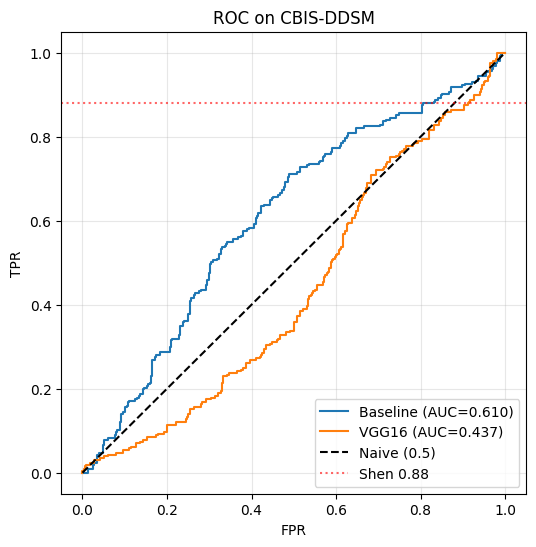

In [ ]:
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

def evaluate(model, name):
    y_prob = model.predict(ds_test, verbose=0).ravel()
    auc = roc_auc_score(y_test, y_prob)
    y_pred = (y_prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    sens = tp/(tp+fn) if (tp+fn) else 0
    spec = tn/(tn+fp) if (tn+fp) else 0
    print(f'\n=== {name} ===')
    print(f'AUC-ROC:     {auc:.3f}')
    print(f'Sensitivity: {sens:.3f}')
    print(f'Specificity: {spec:.3f}')
    print(f'Confusion [tn fp / fn tp]: [{tn} {fp} / {fn} {tp}]')
    return auc, y_prob

auc_b, prob_b = evaluate(baseline, 'Baseline CNN')
auc_v, prob_v = evaluate(vgg, 'VGG16 transfer')

plt.figure(figsize=(6,6))
for name, prob, auc in [('Baseline', prob_b, auc_b), ('VGG16', prob_v, auc_v)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0,1],[0,1],'k--',label='Naive (0.5)')
plt.axhline(0.88, color='r', ls=':', alpha=0.6, label='Shen 0.88')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.legend(); plt.title('ROC on CBIS-DDSM'); plt.grid(alpha=0.3); plt.show()

**Side-by-side Confusion Matrices**

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


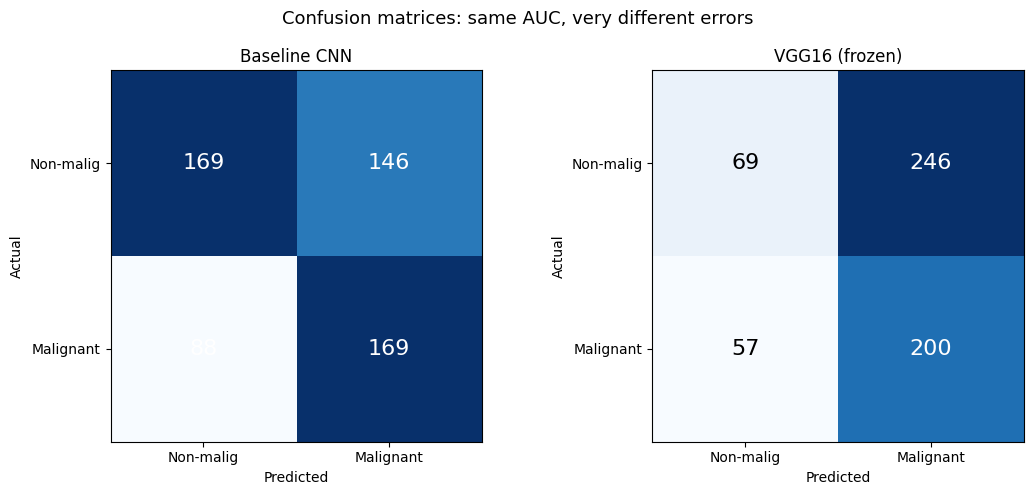

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import itertools

def plot_cm(ax, cm, title):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0,1]); ax.set_xticklabels(['Non-malig','Malignant'])
    ax.set_yticks([0,1]); ax.set_yticklabels(['Non-malig','Malignant'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    for i,j in itertools.product(range(2), range(2)):
        ax.text(j, i, cm[i,j], ha='center', va='center', fontsize=16,
                color='white' if cm[i,j] > cm.max()/2 else 'black')

prob_b = baseline.predict(ds_test, verbose=0).ravel()
prob_v = vgg.predict(ds_test, verbose=0).ravel()
yt = y_test[:len(prob_b)]
cm_b = confusion_matrix(yt, (prob_b>=0.5).astype(int))
cm_v = confusion_matrix(yt, (prob_v>=0.5).astype(int))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11,5))
plot_cm(ax1, cm_b, 'Baseline CNN')
plot_cm(ax2, cm_v, 'VGG16 (frozen)')
plt.suptitle('Confusion matrices: same AUC, very different errors', fontsize=13)
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

**Example Predictions on real mammograms**

In [ ]:
# Show a grid of test images with predicted vs true labels
batch_imgs, batch_lbls = next(iter(ds_test))
preds = vgg.predict(batch_imgs, verbose=0).ravel()

plt.figure(figsize=(14, 7))
for i in range(min(10, len(batch_imgs))):
    plt.subplot(2, 5, i+1)
    plt.imshow(batch_imgs[i].numpy())
    true = 'Malig' if batch_lbls[i]==1 else 'Non-mal'
    pred = 'Malig' if preds[i]>=0.5 else 'Non-mal'
    correct = (batch_lbls[i]==1) == (preds[i]>=0.5)
    plt.title(f'True:{true}\nPred:{pred} ({preds[i]:.2f})',
              color='green' if correct else 'red', fontsize=9)
    plt.axis('off')
plt.suptitle('VGG16 predictions on test mammograms (green=correct, red=wrong)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/example_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

**Training History, showing learning curves**

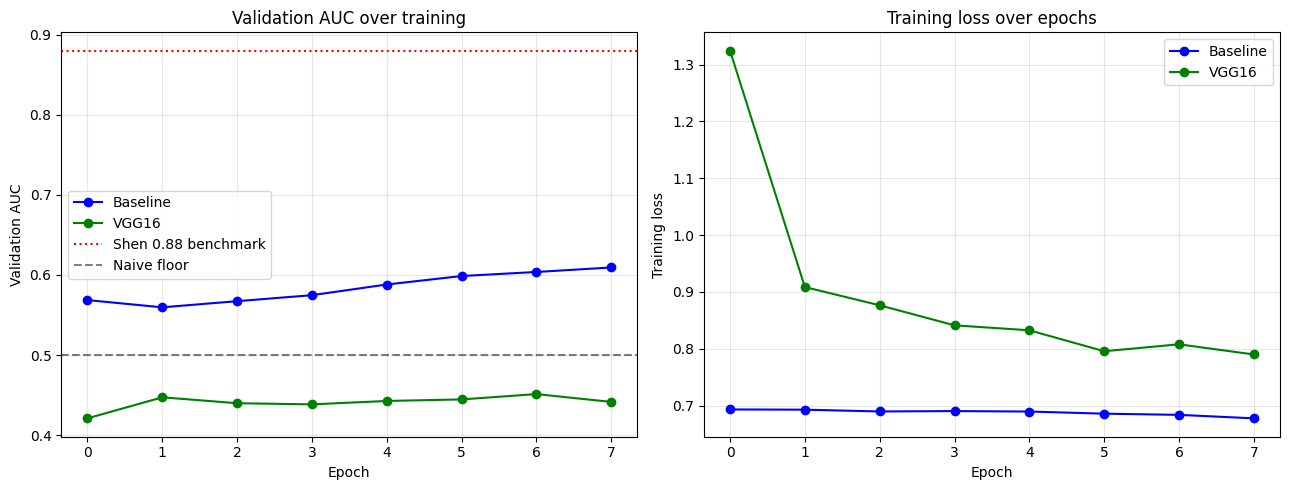

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
ax1.plot(hist_base.history['val_auc'], 'b-o', label='Baseline')
ax1.plot(hist_vgg.history['val_auc'], 'g-o', label='VGG16')
ax1.axhline(0.88, color='r', ls=':', label='Shen 0.88 benchmark')
ax1.axhline(0.5, color='k', ls='--', alpha=0.5, label='Naive floor')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Validation AUC')
ax1.set_title('Validation AUC over training'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(hist_base.history['loss'], 'b-o', label='Baseline')
ax2.plot(hist_vgg.history['loss'], 'g-o', label='VGG16')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Training loss')
ax2.set_title('Training loss over epochs'); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

**Protoype Summary**

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix

BENCHMARK = 0.88  # Shen et al. (2019), CBIS-DDSM single model

def summary(prob, name):
    pred = (prob >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, pred).ravel()
    auc = roc_auc_score(yt, prob)
    gap = auc - BENCHMARK
    print(f"{name:18} | AUC {auc:.3f} | "
          f"Sens {tp/(tp+fn):.3f} | Spec {tn/(tn+fp):.3f} | "
          f"Missed cancers (FN): {fn:3d} | vs benchmark: {gap:+.3f}")

print("=" * 92)
print(f"{'Model':18} | {'AUC':9} | {'Sensitivity':11} | {'Specificity':11} | Missed | Gap to 0.88")
print("-" * 92)
summary(prob_b, "Baseline CNN")
summary(prob_v, "VGG16 (frozen)")
print("-" * 92)
print(f"{'Benchmark':18} | AUC 0.880 | Shen et al. (2019), CBIS-DDSM single model")
print("=" * 92)

Model              | AUC       | Sensitivity | Specificity | Missed | Gap to 0.88
--------------------------------------------------------------------------------------------
Baseline CNN       | AUC 0.610 | Sens 0.658 | Spec 0.537 | Missed cancers (FN):  88 | vs benchmark: -0.270
VGG16 (frozen)     | AUC 0.437 | Sens 0.778 | Spec 0.219 | Missed cancers (FN):  57 | vs benchmark: -0.443
--------------------------------------------------------------------------------------------
Benchmark          | AUC 0.880 | Shen et al. (2019), CBIS-DDSM single model
